# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Thyroid Disease (Sick) Dataset** dari UCI Machine Learning Repository.

- **Nama Dataset**: Thyroid Disease (Sick)
- **Sumber Dataset**: https://archive.ics.uci.edu/ml/datasets/Thyroid+Disease
- **Konteks**: Dataset ini berisi catatan medis pasien untuk menentukan apakah seorang pasien menderita penyakit tiroid (kategori 'sick') atau tidak ('negative').
- **Deskripsi**: Dataset terdiri dari 26 fitur medis, termasuk data demografis (usia, jenis kelamin) dan hasil tes hormon (TSH, T3, TT4, T4U, FTI). Target variabel adalah kolom ke-27 yang menunjukkan status kesehatan pasien.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset mentah dari folder thyroid_raw
df = pd.read_csv("../thyroid_raw/thyroid.csv", header=None, na_values="?")

# Mengambil 27 kolom pertama (fitur + target)
df = df.iloc[:, :27]

print(f"Dimensi dataset: {df.shape}")
df.head()

Dimensi dataset: (2800, 27)


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,41.0,F,f,f,f,f,f,f,f,f,...,1.30,t,2.5,t,125.0,t,1.14,t,109.0,f
1,23.0,F,f,f,f,f,f,f,f,f,...,4.10,t,2.0,t,102.0,f,NaN,f,NaN,f
2,46.0,M,f,f,f,f,f,f,f,f,...,0.98,f,NaN,t,109.0,t,0.91,t,120.0,f
3,70.0,F,t,f,f,f,f,f,f,f,...,0.16,t,1.9,t,175.0,f,NaN,f,NaN,f
4,70.0,F,f,f,f,f,f,f,f,f,...,0.72,t,1.2,t,61.0,t,0.87,t,70.0,f


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2799 non-null   float64
 1   1       2690 non-null   object 
 2   2       2800 non-null   object 
 3   3       2800 non-null   object 
 4   4       2800 non-null   object 
 5   5       2800 non-null   object 
 6   6       2800 non-null   object 
 7   7       2800 non-null   object 
 8   8       2800 non-null   object 
 9   9       2800 non-null   object 
 10  10      2800 non-null   object 
 11  11      2800 non-null   object 
 12  12      2800 non-null   object 
 13  13      2800 non-null   object 
 14  14      2800 non-null   object 
 15  15      2800 non-null   object 
 16  16      2800 non-null   object 
 17  17      2516 non-null   float64
 18  18      2800 non-null   object 
 19  19      2215 non-null   float64
 20  20      2800 non-null   object 
 21  21      2616 non-null   float64
 22  

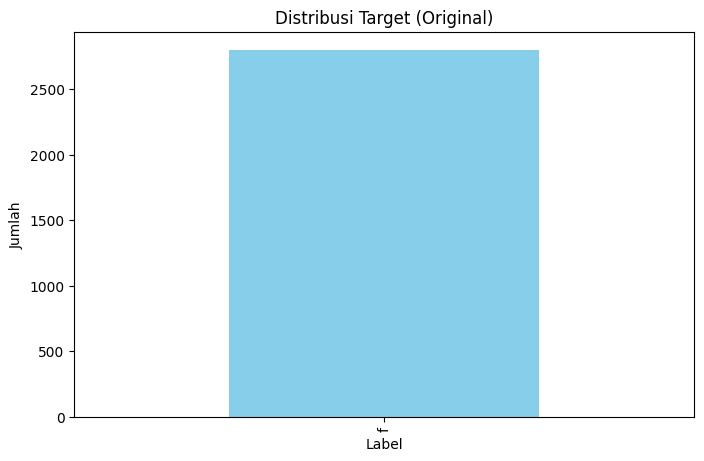

,0,17,19,21,23,25
count,2799.00000,2516.000000,2215.000000,2616.000000,2503.000000,2505.000000
mean,51.84423,4.672150,2.024966,109.072401,0.997912,110.787984
std,20.46116,21.449453,0.824600,35.392443,0.194390,32.883986
min,1.00000,0.005000,0.050000,2.000000,0.310000,2.000000
25%,36.00000,0.440000,1.600000,88.000000,0.880000,93.000000
50%,54.00000,1.400000,2.000000,104.000000,0.980000,107.000000
75%,67.00000,2.600000,2.400000,125.000000,1.080000,124.000000
max,455.00000,478.000000,10.600000,430.000000,2.120000,395.000000


In [3]:
# Melihat info dataset
print(df.info())

# Melihat distribusi target
plt.figure(figsize=(8, 5))
df[26].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Target (Original)')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

# Melihat statistik deskriptif untuk kolom numerik
df.describe()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Menghapus Missing Values
df_cleaned = df.dropna()

# 2. Encoding Data Kategorikal dan Cleaning Target
le = LabelEncoder()
for col in df_cleaned.columns:
    # Target berada di kolom index 26
    if col == 26:
        # Menghapus suffix pada target (misal 'negative.|3733' -> 'negative')
        df_cleaned[col] = df_cleaned[col].str.split('.').str[0]
    
    # Encoding fitur kategorikal ke numerik
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

print(f"Jumlah sampel setelah cleaning: {len(df_cleaned)}")

# 3. Menyimpan data hasil preprocessing (Wajib sesuai feedback reviewer)
os.makedirs('thyroid_preprocessing', exist_ok=True)
df_cleaned.to_csv('thyroid_preprocessing/thyroid_cleaned.csv', index=False)
print("Data hasil preprocessing telah disimpan ke folder 'thyroid_preprocessing'.")

df_cleaned.head()

Jumlah sampel setelah cleaning: 1947
Data hasil preprocessing telah disimpan ke folder 'thyroid_preprocessing'.


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,41.0,0,0,0,0,0,0,0,0,0,...,1.30,0,2.5,0,125.0,0,1.14,0,109.0,0
4,70.0,0,0,0,0,0,0,0,0,0,...,0.72,0,1.2,0,61.0,0,0.87,0,70.0,0
7,80.0,0,0,0,0,0,0,0,0,0,...,2.20,0,0.6,0,80.0,0,0.70,0,115.0,0
8,66.0,0,0,0,0,0,0,0,0,0,...,0.60,0,2.2,0,123.0,0,0.93,0,132.0,0
9,68.0,1,0,0,0,0,0,0,0,0,...,2.40,0,1.6,0,83.0,0,0.89,0,93.0,0
